# 07 — Epoch Plots

Trains every model in the `models` dict for 3 stratified folds and plots:
- **Accuracy per epoch** (train vs validation, mean ± std across folds)
- **Loss per epoch** (train vs validation, mean ± std across folds)

Plots are saved to `outputs/epoch_plots/`.

In [1]:
import sys
sys.path.insert(0, '../src')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

from models import models, _set_seed
from augmentation import augments, _build_eval_transform
from dataset import train_csv_path, train_img_folder_path, DigitDataset
from utils import _get_device

os.makedirs('../outputs/epoch_plots', exist_ok=True)
print('Device:', _get_device())

Device: cuda


In [2]:
# --- Config ---
EPOCHS     = 10
BATCH_SIZE = 128
LR         = 0.01
N_FOLDS    = 3
AUGM_NAME  = 'mild_no_stroke'
augm_fn    = augments[AUGM_NAME]
eval_fn    = _build_eval_transform()
device     = _get_device()

In [3]:
def train_fold_with_history(model_fn, train_df, val_df, epochs, lr, batch_size, device, seed=42):
    """Train one fold and return per-epoch train/val loss and accuracy."""
    _set_seed(seed)

    train_set = DigitDataset(csv_path=train_csv_path, img_path=train_img_folder_path,
                             transform=augm_fn, df=train_df)
    val_set   = DigitDataset(csv_path=train_csv_path, img_path=train_img_folder_path,
                             transform=eval_fn, df=val_df)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=2, persistent_workers=True)
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False,
                              num_workers=2, persistent_workers=True)

    model     = model_fn().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    loss_fn   = nn.CrossEntropyLoss()

    use_amp   = device.type in ('cuda', 'mps')
    scaler    = torch.amp.GradScaler(enabled=device.type == 'cuda')
    amp_dtype = torch.float16 if device.type == 'cuda' else torch.bfloat16

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # Train
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for images, targets in tqdm(train_loader, desc=f'  Epoch {epoch+1:>2}/{epochs}', leave=False):
            images  = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=use_amp, dtype=amp_dtype):
                logits = model(images)
                loss   = loss_fn(logits, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            t_loss    += loss.item() * len(targets)
            t_correct += (logits.detach().argmax(1) == targets).sum().item()
            t_total   += len(targets)

        history['train_loss'].append(t_loss    / t_total)
        history['train_acc'].append( t_correct / t_total * 100)

        # Validate
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for images, targets in val_loader:
                images  = images.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True)
                logits  = model(images)
                v_loss    += loss_fn(logits, targets).item() * len(targets)
                v_correct += (logits.argmax(1) == targets).sum().item()
                v_total   += len(targets)

        history['val_loss'].append(v_loss    / v_total)
        history['val_acc'].append( v_correct / v_total * 100)

        print(f'  Epoch {epoch+1:>2}/{epochs} | '
              f'train loss={history["train_loss"][-1]:.4f}  acc={history["train_acc"][-1]:.1f}% | '
              f'val loss={history["val_loss"][-1]:.4f}  acc={history["val_acc"][-1]:.1f}%')

    return history

In [4]:
def k_fold_with_history(model_name, model_fn, df, n_folds=N_FOLDS, epochs=EPOCHS,
                        batch_size=BATCH_SIZE, lr=LR, device=device):
    """Run k-fold CV and return a list of per-epoch history dicts (one per fold)."""
    y     = df['Category'].tolist()
    kfold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_histories = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(np.zeros(len(df)), y)):
        print(f'\n[{model_name}] Fold {fold+1}/{n_folds}')
        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df   = df.iloc[val_idx  ].reset_index(drop=True)
        h = train_fold_with_history(model_fn, train_df, val_df,
                                    epochs, lr, batch_size, device, seed=42 + fold)
        fold_histories.append(h)

    return fold_histories

In [5]:
def plot_model_history(model_name, fold_histories, epochs=EPOCHS,
                       save_dir='../outputs/epoch_plots'):
    epoch_range = np.arange(1, epochs + 1)
    fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(model_name, fontsize=15, fontweight='bold')

    for key, color, label in [('train_acc', 'steelblue', 'Train'),
                               ('val_acc',   'coral',     'Validation')]:
        vals       = np.array([h[key] for h in fold_histories])
        mu, sigma  = vals.mean(0), vals.std(0)
        ax_acc.plot(epoch_range, mu, color=color, label=label, linewidth=2)
        ax_acc.fill_between(epoch_range, mu - sigma, mu + sigma, color=color, alpha=0.2)
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy (%)')
    ax_acc.set_title('Accuracy per Epoch')
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

    for key, color, label in [('train_loss', 'steelblue', 'Train'),
                               ('val_loss',   'coral',     'Validation')]:
        vals       = np.array([h[key] for h in fold_histories])
        mu, sigma  = vals.mean(0), vals.std(0)
        ax_loss.plot(epoch_range, mu, color=color, label=label, linewidth=2)
        ax_loss.fill_between(epoch_range, mu - sigma, mu + sigma, color=color, alpha=0.2)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.set_title('Loss per Epoch')
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    path = f'{save_dir}/{model_name}_epoch_plots.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {path}')


Training: scnn_stride

[scnn_stride] Fold 1/3


  Epoch  1/10 | train loss=1.4849  acc=51.3% | val loss=0.7399  acc=72.4%


  Epoch  2/10 | train loss=0.2301  acc=93.0% | val loss=0.1536  acc=95.4%


  Epoch  3/10 | train loss=0.1061  acc=96.8% | val loss=0.0510  acc=98.4%


  Epoch  4/10 | train loss=0.0643  acc=98.1% | val loss=0.2762  acc=90.5%


...

  Epoch  6/10 | train loss=0.0377  acc=98.8% | val loss=0.0282  acc=99.3%


  Epoch  7/10 | train loss=0.0429  acc=98.7% | val loss=0.0239  acc=99.2%


  Epoch  8/10 | train loss=0.0321  acc=99.0% | val loss=0.0132  acc=99.7%


  Epoch  9/10 | train loss=0.0260  acc=99.2% | val loss=0.0213  acc=99.4%


  Epoch 10/10 | train loss=0.0219  acc=99.3% | val loss=0.0154  acc=99.6%


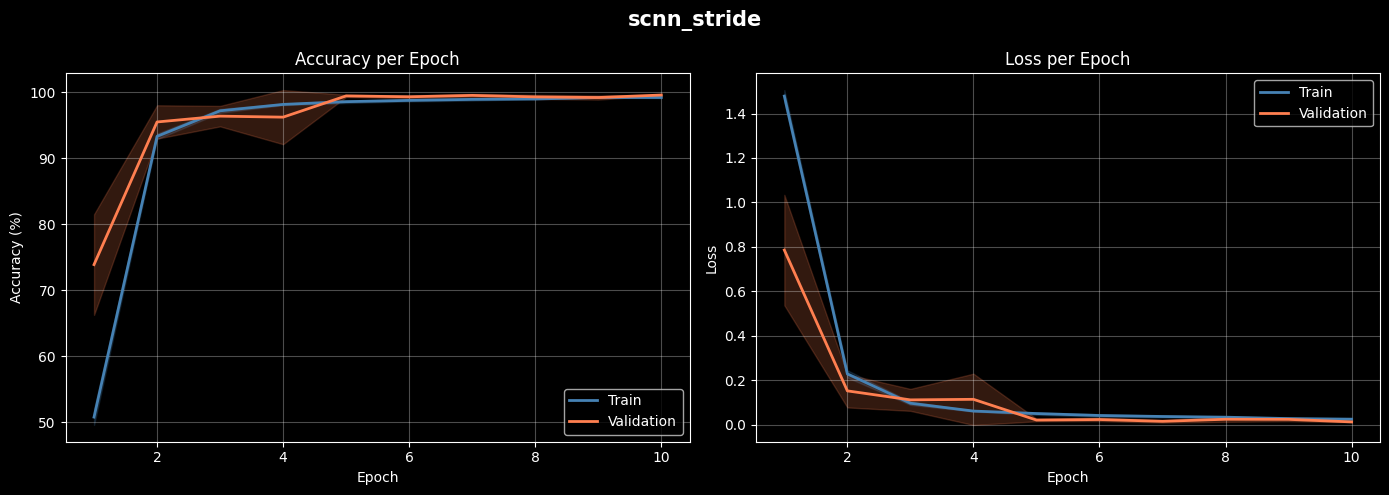

Saved → ../outputs/epoch_plots/scnn_stride_epoch_plots.png

Training: scnn_dilated

[scnn_dilated] Fold 1/3


  Epoch  1/10 | train loss=1.0321  acc=68.3% | val loss=0.3111  acc=88.8%


  Epoch  2/10 | train loss=0.1809  acc=95.5% | val loss=0.0379  acc=98.8%


  Epoch  3/10 | train loss=0.0983  acc=97.6% | val loss=0.0832  acc=97.0%


  Epoch  4/10 | train loss=0.0708  acc=98.2% | val loss=0.0188  acc=99.5%


...

  Epoch  6/10 | train loss=0.0522  acc=98.6% | val loss=0.0215  acc=99.4%


  Epoch  7/10 | train loss=0.0395  acc=98.9% | val loss=0.0121  acc=99.7%


  Epoch  8/10 | train loss=0.0373  acc=99.0% | val loss=0.0270  acc=99.3%


  Epoch  9/10 | train loss=0.0325  acc=99.2% | val loss=0.0116  acc=99.7%


  Epoch 10/10 | train loss=0.0310  acc=99.2% | val loss=0.0101  acc=99.8%


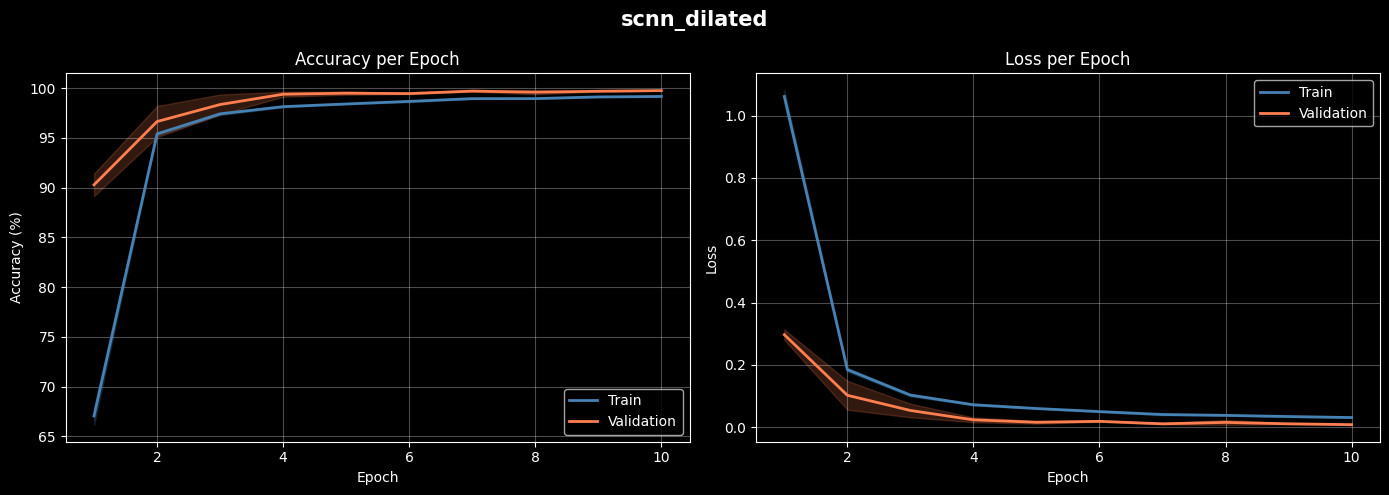

Saved → ../outputs/epoch_plots/scnn_dilated_epoch_plots.png

Training: resnet_se

[resnet_se] Fold 1/3


  Epoch  1/10 | train loss=1.2708  acc=57.9% | val loss=0.2881  acc=92.2%


  Epoch  2/10 | train loss=0.2426  acc=93.4% | val loss=0.0725  acc=98.1%


  Epoch  3/10 | train loss=0.1234  acc=96.8% | val loss=0.0357  acc=99.1%


  Epoch  4/10 | train loss=0.0790  acc=98.0% | val loss=0.0265  acc=99.4%


...

  Epoch  6/10 | train loss=0.0538  acc=98.6% | val loss=0.0250  acc=99.2%


  Epoch  7/10 | train loss=0.0434  acc=98.9% | val loss=0.0233  acc=99.4%


  Epoch  8/10 | train loss=0.0386  acc=99.0% | val loss=0.0220  acc=99.4%


  Epoch  9/10 | train loss=0.0382  acc=98.9% | val loss=0.0247  acc=99.2%


  Epoch 10/10 | train loss=0.0314  acc=99.1% | val loss=0.0136  acc=99.7%


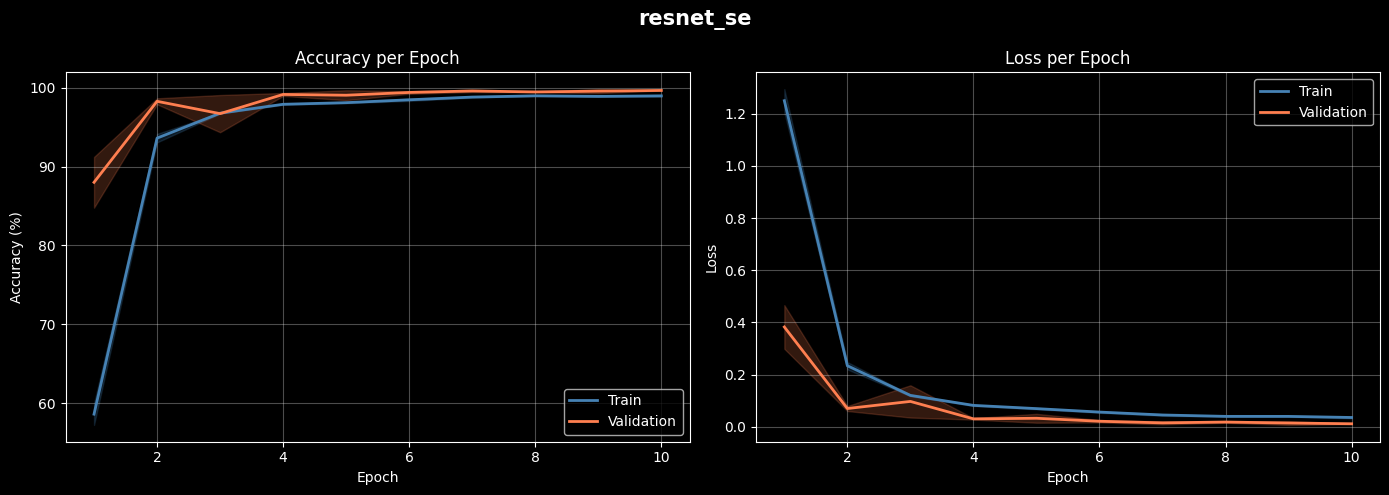

Saved → ../outputs/epoch_plots/resnet_se_epoch_plots.png

Training: resnet_lean

[resnet_lean] Fold 1/3


  Epoch  1/10 | train loss=1.2904  acc=57.2% | val loss=0.4106  acc=87.5%


  Epoch  2/10 | train loss=0.3070  acc=91.0% | val loss=0.0973  acc=96.9%


  Epoch  3/10 | train loss=0.1647  acc=95.3% | val loss=0.0823  acc=97.5%


  Epoch  4/10 | train loss=0.1174  acc=96.7% | val loss=0.0882  acc=97.2%


...

  Epoch  6/10 | train loss=0.0703  acc=98.0% | val loss=0.0367  acc=99.0%


  Epoch  7/10 | train loss=0.0616  acc=98.4% | val loss=0.0245  acc=99.3%


  Epoch  8/10 | train loss=0.0531  acc=98.6% | val loss=0.0193  acc=99.5%


  Epoch  9/10 | train loss=0.0503  acc=98.7% | val loss=0.0157  acc=99.5%


  Epoch 10/10 | train loss=0.0414  acc=98.8% | val loss=0.0236  acc=99.3%


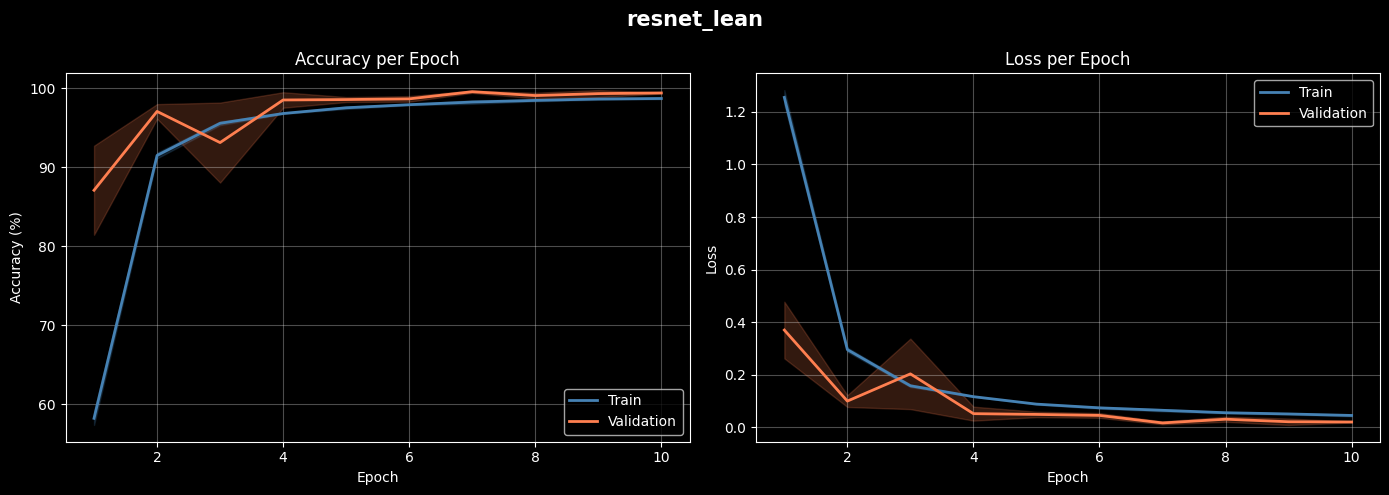

Saved → ../outputs/epoch_plots/resnet_lean_epoch_plots.png

Training: scnn_baseline

[scnn_baseline] Fold 1/3


  Epoch  1/10 | train loss=1.1365  acc=65.1% | val loss=0.2708  acc=91.8%


  Epoch  2/10 | train loss=0.2356  acc=94.4% | val loss=0.0917  acc=97.7%


  Epoch  3/10 | train loss=0.1244  acc=97.1% | val loss=0.0496  acc=98.8%


  Epoch  4/10 | train loss=0.0879  acc=97.9% | val loss=0.0267  acc=99.4%


...

  Epoch  6/10 | train loss=0.0650  acc=98.3% | val loss=0.0246  acc=99.4%


  Epoch  7/10 | train loss=0.0538  acc=98.7% | val loss=0.0186  acc=99.6%


  Epoch  8/10 | train loss=0.0498  acc=98.7% | val loss=0.0209  acc=99.4%


  Epoch  9/10 | train loss=0.0447  acc=98.9% | val loss=0.0194  acc=99.5%


  Epoch 10/10 | train loss=0.0364  acc=99.1% | val loss=0.0150  acc=99.6%


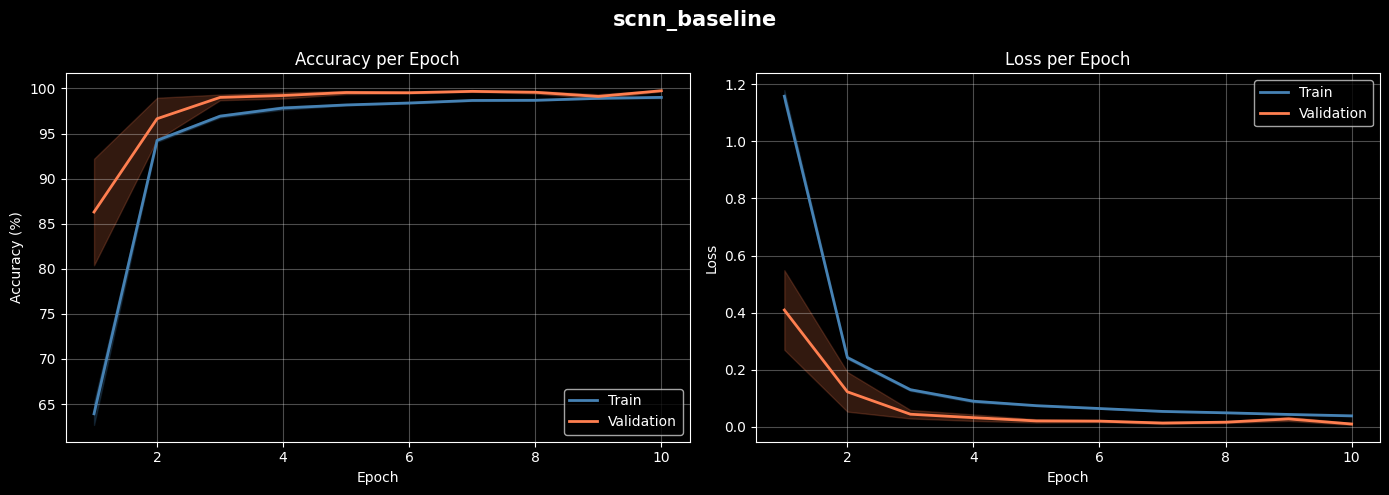

Saved → ../outputs/epoch_plots/scnn_baseline_epoch_plots.png

Training: scnn_3conv

[scnn_3conv] Fold 1/3


  Epoch  1/10 | train loss=0.9051  acc=72.3% | val loss=0.3092  acc=88.6%


  Epoch  2/10 | train loss=0.1228  acc=97.2% | val loss=0.0966  acc=97.0%


  Epoch  3/10 | train loss=0.0674  acc=98.5% | val loss=0.0328  acc=99.3%


  Epoch  4/10 | train loss=0.0554  acc=98.7% | val loss=0.0311  acc=99.1%


...

  Epoch  6/10 | train loss=0.0356  acc=99.1% | val loss=0.0225  acc=99.4%


  Epoch  7/10 | train loss=0.0322  acc=99.2% | val loss=0.0183  acc=99.5%


  Epoch  8/10 | train loss=0.0298  acc=99.3% | val loss=0.0104  acc=99.8%


  Epoch  9/10 | train loss=0.0230  acc=99.4% | val loss=0.0377  acc=99.0%


  Epoch 10/10 | train loss=0.0194  acc=99.5% | val loss=0.0104  acc=99.8%


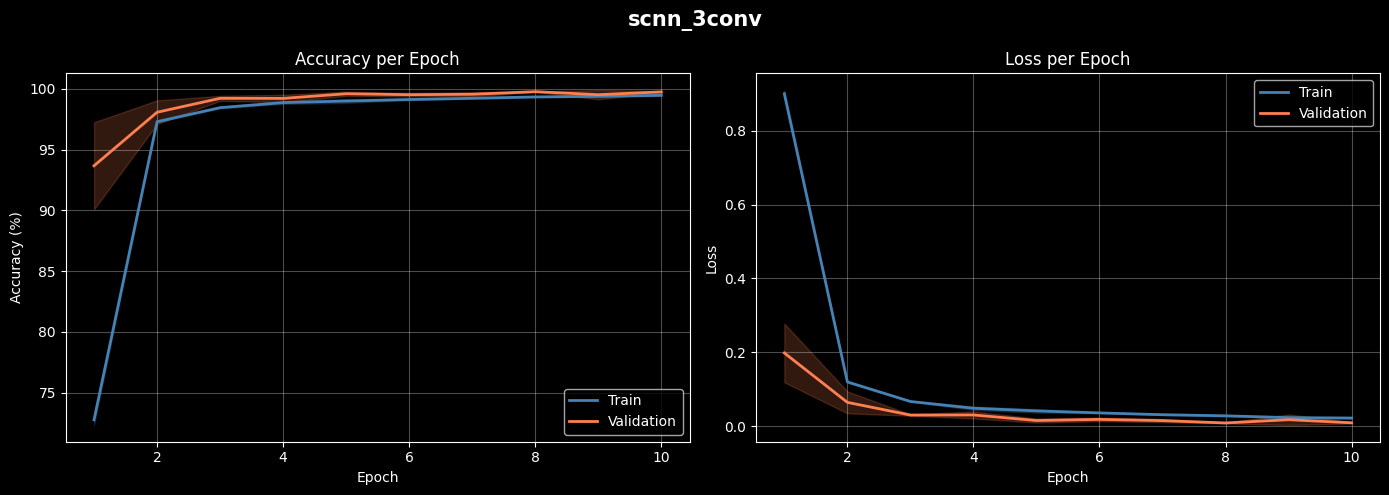

Saved → ../outputs/epoch_plots/scnn_3conv_epoch_plots.png


In [6]:
df_train = pd.read_csv(train_csv_path)
all_histories = {}

for model_name, model_fn in models.items():
    print(f'\n==============================\nTraining: {model_name}\n==============================')
    fold_histories = k_fold_with_history(model_name, model_fn, df_train)
    all_histories[model_name] = fold_histories
    plot_model_history(model_name, fold_histories)

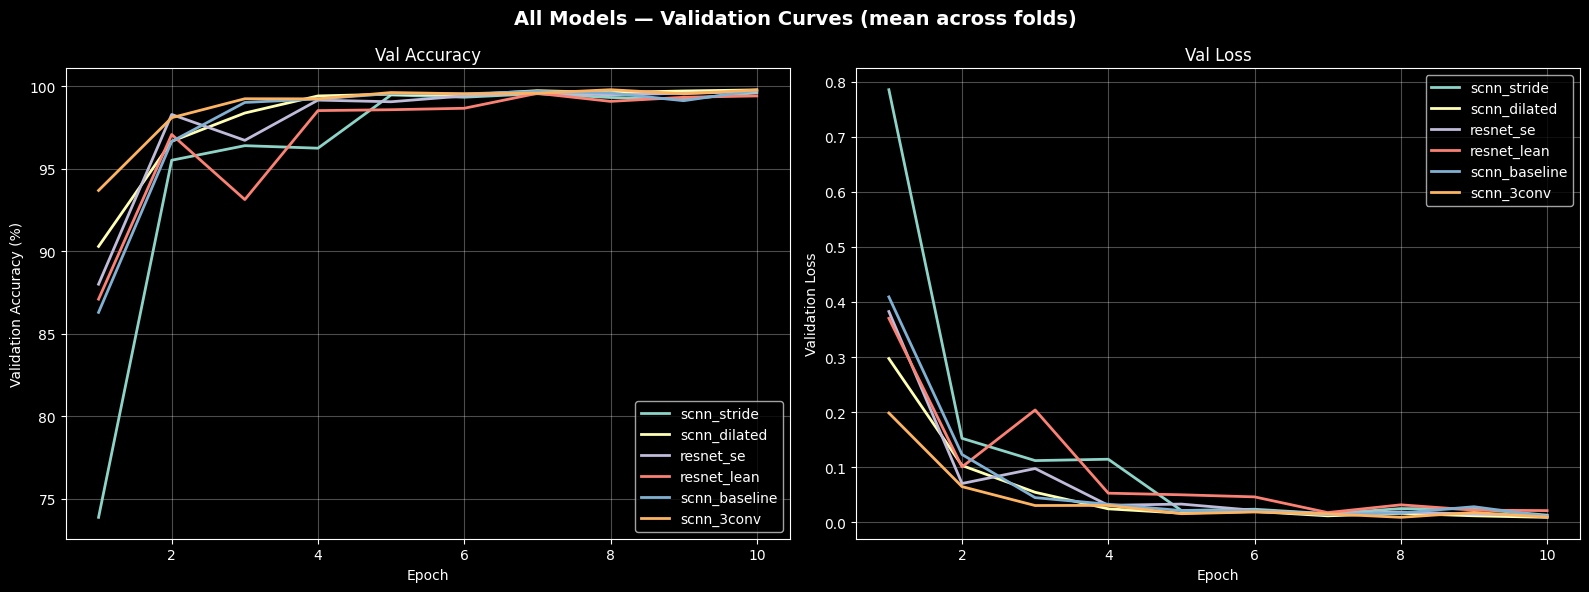

Saved → ../outputs/epoch_plots/all_models_comparison.png


In [7]:
# --- Comparison: val accuracy of all models on one plot ---
epoch_range = np.arange(1, EPOCHS + 1)
fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('All Models — Validation Curves (mean across folds)', fontsize=14, fontweight='bold')

for model_name, fold_histories in all_histories.items():
    acc_vals  = np.array([h['val_acc' ] for h in fold_histories])
    loss_vals = np.array([h['val_loss'] for h in fold_histories])
    ax_acc.plot( epoch_range, acc_vals.mean(0),  label=model_name, linewidth=2)
    ax_loss.plot(epoch_range, loss_vals.mean(0), label=model_name, linewidth=2)

ax_acc.set_xlabel('Epoch');  ax_acc.set_ylabel('Validation Accuracy (%)')
ax_acc.set_title('Val Accuracy');  ax_acc.legend();  ax_acc.grid(True, alpha=0.3)

ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Validation Loss')
ax_loss.set_title('Val Loss');  ax_loss.legend();  ax_loss.grid(True, alpha=0.3)

plt.tight_layout()
path = '../outputs/epoch_plots/all_models_comparison.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')